In [ ]:
import win32com.client as win32
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

from economic_analysis import annual_utility_cost
from economic_analysis import total_energy

In [ ]:
BASE_DIR = Path.cwd() 
MODEL_PATH = BASE_DIR.parent / "aspen-model" / "ethyl-acetate-optimization - heat integration.bkp"

aspen = win32.Dispatch("Apwn.Document")
aspen.InitFromArchive2(str(MODEL_PATH))

In [3]:
aspen.Tree.FindNode(
    r"\Data\Blocks\RADFRAC1\Input\PRES1"
).Value = 1.0

aspen.Tree.FindNode(
    r"\Data\Streams\ETH-ACE\Input\FLOW\MIXED\ETHANOL"
).Value = 50

aspen.Tree.FindNode(
    r"\Data\Streams\ETH-ACE\Input\FLOW\MIXED\ACETI-01"
).Value = 50

aspen.Engine.Run2()

In [4]:
rr_values = np.arange(1.0, 5.5, 0.5)

results = []

In [6]:
for rr in rr_values:

    print(f"Running RR = {rr:.1f}")


    aspen.Tree.FindNode(
        r"\Data\Blocks\RADFRAC1\Input\BASIS_RR"
    ).Value = rr

    aspen.Engine.Run2()


    purity = aspen.Tree.FindNode(
        r"\Data\Streams\LIQ-DIST\Output\MOLEFRAC\MIXED\ETHYL-01"
    ).Value

    condenser = aspen.Tree.FindNode(
        r"\Data\Blocks\RADFRAC1\Output\COND_DUTY"
    ).Value

    reboiler = aspen.Tree.FindNode(
        r"\Data\Blocks\RADFRAC1\Output\REB_DUTY"
    ).Value
    
    cost = annual_utility_cost(        
    condenser,
    reboiler)

    energy = total_energy(
    condenser,
    reboiler)

    results.append([
    rr,
    purity,
    condenser,
    reboiler,
    energy,
    cost])

Running RR = 1.0
Running RR = 1.5
Running RR = 2.0
Running RR = 2.5
Running RR = 3.0
Running RR = 3.5
Running RR = 4.0
Running RR = 4.5
Running RR = 5.0


In [25]:
df = pd.DataFrame(
    results,
    columns=[
        "Reflux Ratio",
        "Purity",
        "Condenser Duty",
        "Reboiler Duty",
        "Total Energy",
        "Annual Utility Cost"
    ]
)
df = df.sort_values("Reflux Ratio")

os.makedirs("data", exist_ok=True)
df.to_csv("data/rr_results.csv", index=False)

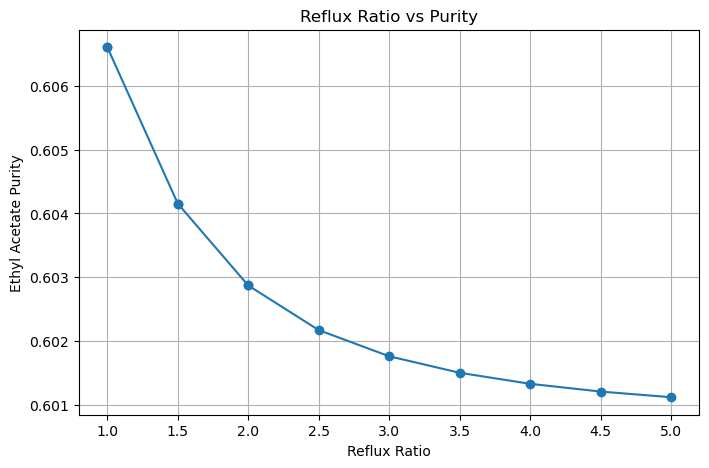

In [21]:
plt.figure(figsize=(8,5))
plt.plot(df["Reflux Ratio"], df["Purity"], marker="o")
plt.xlabel("Reflux Ratio")
plt.ylabel("Ethyl Acetate Purity")
plt.title("Reflux Ratio vs Purity")
plt.grid(True)
plt.show()

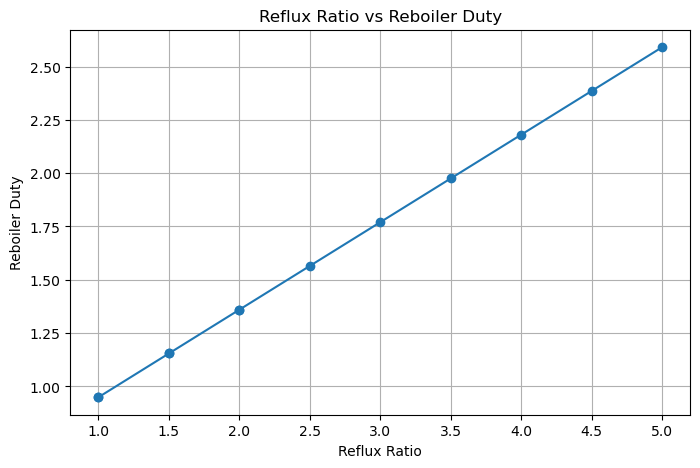

In [22]:
plt.figure(figsize=(8,5))
plt.plot(df["Reflux Ratio"], df["Reboiler Duty"], marker="o")
plt.xlabel("Reflux Ratio")
plt.ylabel("Reboiler Duty")
plt.title("Reflux Ratio vs Reboiler Duty")
plt.grid(True)
plt.show()

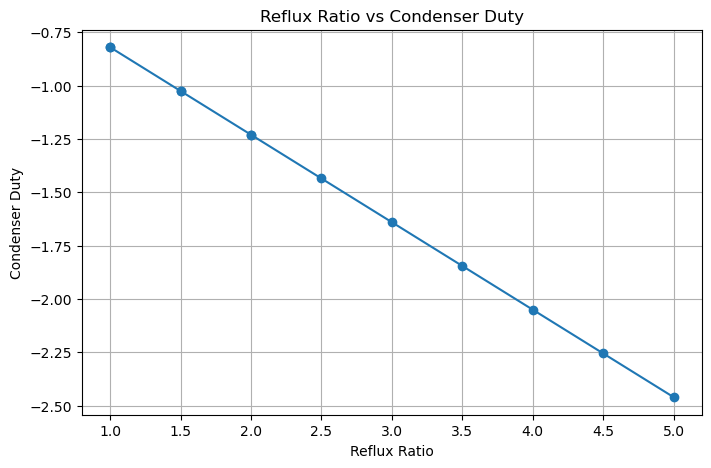

In [23]:
plt.figure(figsize=(8,5))
plt.plot(df["Reflux Ratio"], df["Condenser Duty"], marker="o")
plt.xlabel("Reflux Ratio")
plt.ylabel("Condenser Duty")
plt.title("Reflux Ratio vs Condenser Duty")
plt.grid(True)
plt.show()

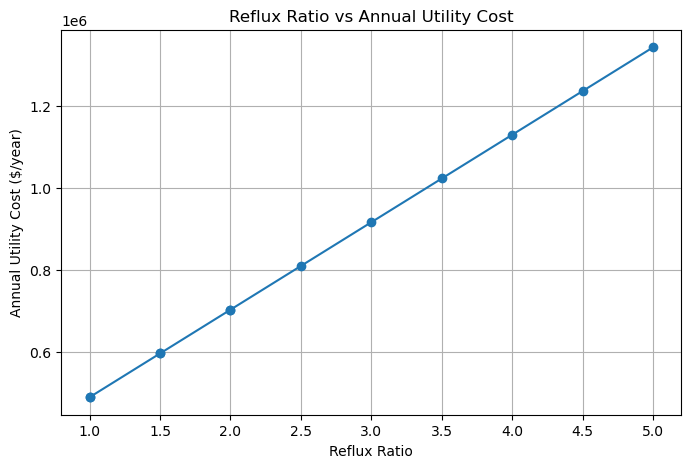

In [24]:
plt.figure(figsize=(8,5))
plt.plot(df["Reflux Ratio"], df["Annual Utility Cost"], marker="o")
plt.xlabel("Reflux Ratio")
plt.ylabel("Annual Utility Cost ($/year)")
plt.title("Reflux Ratio vs Annual Utility Cost")
plt.grid(True)
plt.show()

In [26]:
aspen.Close()
del aspen